# Instance-Based Classification ($k$-NN)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/konstantin-schekotihin/dl_course/blob/master/AI-ML/01_classifiers-kNN.ipynb)


In [1]:
# Setup & configuration (skip in presentation slides)
%matplotlib inline
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from ipywidgets import interact, widgets

# Ensure helpers.py is available (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/AI-ML/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp

# Base URL for course datasets (configurable via environment variable)



## 1. Problem Formulation: The Botanical Use Case

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/slide4.png" width="60%"/>
</center>

### Formalizing the Learning Task: $(T, P, E)$

Our neighbor likes flowers and has lots of them in her garden. Sometimes she forgets how to distinguish different species and then you have to search the Web for descriptions. This is quite tedious and takes lots of time. Therefore you decided to automate this process.

- **Task**: differentiate between flowers
- **Performance measure**: the accuracy of classification must be maximized - ratio of the number of correct answers to the number of incorrect ones.


### Identifying Training Experience ($E$)

- When $T$ and $P$ are defined you start the analysis of the environment to define the training experience 

- Possibilities: flower beds are labeled - labeled data is available
    + make photos of flowers
    + measure some flower parameters: petal/sepal length/width
    + use you new electronic odometer to record smells
    + all together or some subset of the above

### Data Acquisition & Simplification Assumptions 

<center>
    <img src="https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/shared/images/slide8.png" width="50%"/>
</center>

- **Training experience**: measurements of petal/sepal length/width
    + not so much data as for photos (different perspectives)
    + easy to measure comparing to the electronic odometer

- **Assumptions**: simplifications of the real-world
    + the noise in measurements or flower seeds is negligible
    + we take 50 samples of every specie and assume that are they representative

### Formal Matrix Representation: Features & Labels

- **Feature Matrix (Design Matrix)** $\mathbf{X} \in \mathbb{R}^{N \times D}$:
  - $N = 150$: total flower observations ($50$ per species across $C = 3$ species).
  - $D = 4$: feature dimensionality (sepal length, sepal width, petal length, petal width).
  - *Terminology*: Modern ML calls $\mathbf{X}$ the **Feature Matrix** (or Data Matrix); classical statistics terms it the **Design Matrix** (derived from Ronald Fisher's experimental design).

$$
\mathbf{X} =
\begin{bmatrix}
    x_{11} & x_{12} & x_{13} & x_{14} \\
    x_{21} & x_{22} & x_{23} & x_{24} \\
    \vdots & \vdots & \vdots & \vdots \\
    x_{N1} & x_{N2} & x_{N3} & x_{N4}
\end{bmatrix}, \quad
\mathbf{t} =
\begin{bmatrix}
    t_{1} \\
    t_{2} \\
    \vdots \\
    t_{N}
\end{bmatrix}
$$

- **Target Vector** $\mathbf{t} \in \mathcal{C}^N$: discrete labels $t_n \in \mathcal{C} = \{\text{setosa}, \text{versicolor}, \text{virginica}\}$, with $C = |\mathcal{C}| = 3$.


In [2]:
# Load the Iris dataset
iris = sns.load_dataset("iris")

# Display first 5 samples
iris.head(5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
def f(x) : return iris.loc[iris.species==x].describe()
interact(f, x=['setosa','versicolor','virginica']);

interactive(children=(Dropdown(description='x', options=('setosa', 'versicolor', 'virginica'), value='setosa')…

In [4]:
def plt_stats(specie='none'):
    t = iris if specie == 'none' else iris.loc[iris.species == specie]
    sns.boxplot(data=t)
    plt.show()

interact(plt_stats, specie=['none', 'setosa', 'virginica', 'versicolor']);


interactive(children=(Dropdown(description='specie', options=('none', 'setosa', 'virginica', 'versicolor'), va…

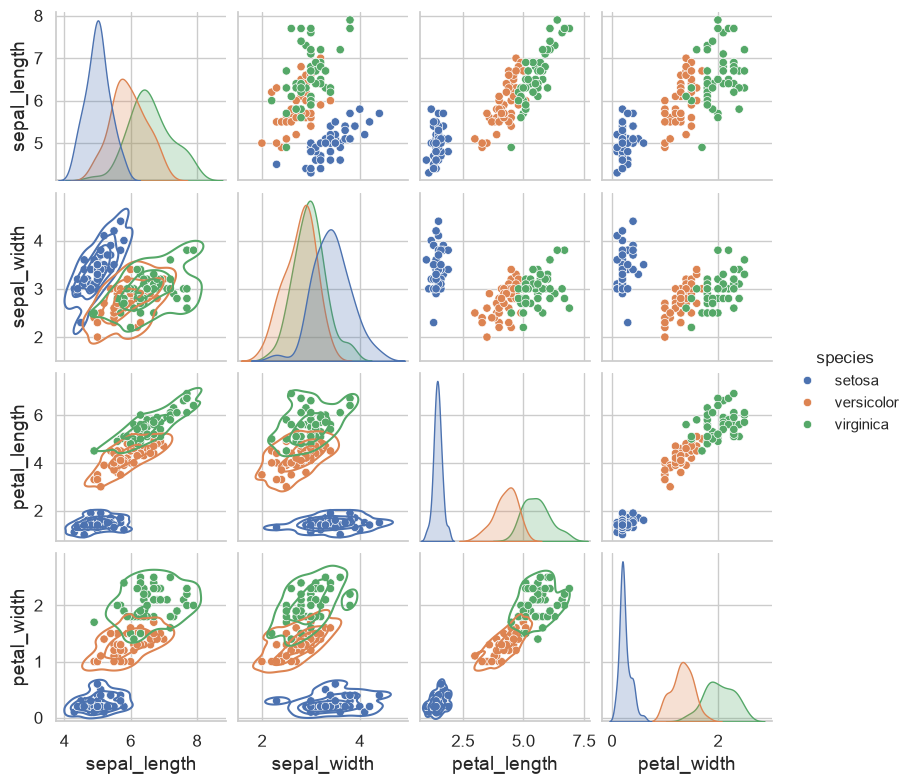

In [5]:
fig = sns.pairplot(iris, hue="species", height=2)
fig.map_lower(sns.kdeplot, levels=4, color=".2");

## 2. Exploratory Data Analysis & Feature Correlation

- **Correlation** quantifies the linear statistical association between continuous feature variables $x$ and $y$ (e.g., sepal length and petal length) across $N = 150$ samples.
- **Sample Pearson Correlation Coefficient** $r_{xy} \in [-1, 1]$:

$$
r_{xy} = \frac{\sum_{n=1}^{N} (x_n - \bar{x})(y_n - \bar{y})}{\sqrt{\sum_{n=1}^{N} (x_n - \bar{x})^2} \sqrt{\sum_{n=1}^{N} (y_n - \bar{y})^2}}
$$

  where $\bar{x} = \frac{1}{N}\sum_{n=1}^N x_n$ and $\bar{y} = \frac{1}{N}\sum_{n=1}^N y_n$ are the sample means.
- **Population Correlation ($\rho$)**: $r_{xy}$ estimates the true underlying population correlation parameter $\rho$.


- **Linearity & Modeling**: Pearson's $r_{xy}$ measures the strength of *linear* relationships (crucial for models like linear regression that assume a linear function).
- **Sensitivity to Outliers**: Pearson correlation is non-robust to extreme values; isolated outliers can disproportionately inflate or attenuate $r_{xy}$.
- **Monotonic & Non-Linear Relations**: *Spearman rank correlation* ($\rho_s$) evaluates monotonic associations and provides robustness to outliers by operating on rank orders rather than raw metric values.


              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


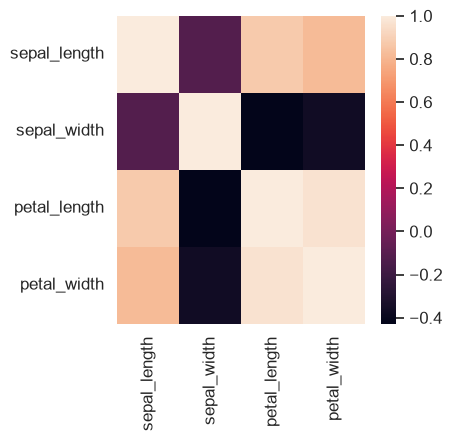

In [6]:
t = iris.iloc[:,0:4].corr()
plt.figure(figsize=(4,4))
print(t)
sns.heatmap(t);

### Significance of Correlation Coefficients & Assumptions

- **Sample vs. Population**: Because $r_{xy}$ is calculated on a finite sample ($N = 150$), we test whether the estimated association reflects a real underlying population correlation $\rho$.
    - $H_0: \rho = 0$ (no linear correlation; observed value is due to sample variation).
    - $H_1: \rho \neq 0$ (statistically significant linear correlation).
- **Prerequisites for Parametric Inference ($t$-Test)**:
    - **Continuous Scale & Linearity**: Variables must be continuous with an underlying linear relationship.
    - **Bivariate Normality**: Feature pairs follow $\begin{pmatrix} x \\ y \end{pmatrix} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$, which guarantees the test statistic follows Student's $t$-distribution under $H_0$.
    - **Homoscedasticity & Independence**: Uniform variance across observations, with independent samples $(x_n, y_n)$.
- **$p$-Value**: Quantifies evidence against $H_0$; the probability of observing $|t| \ge |t_{\mathrm{obs}}|$ by chance under $H_0$.


### Statistical Significance & $p$-Values

- **Hypothesis Testing**: $H_0: \rho = 0$ (no linear correlation) vs. $H_1: \rho \neq 0$ (statistically significant correlation).
- **Two-Tailed $t$-Statistic** for sample correlation $r_{xy}$ on sample size $N = 150$:

$$
t = r_{xy} \sqrt{\frac{N - 2}{1 - r_{xy}^2}}
$$

- **Degrees of Freedom ($\nu = N - 2$)**: Estimating sample means ($\bar{x}, \bar{y}$) consumes 2 degrees of freedom, leaving $\nu = 148$ independent pieces of information.
- **Student's $t$-Distribution ($t_{\nu}$)**: Under $H_0$ and the bivariate normality assumption, test statistic $t$ follows Student's $t$-distribution with $\nu$ degrees of freedom ($t \sim t_{\nu}$), a bell-shaped distribution with heavier tails than Gaussian to account for variance estimation.
- **$p$-Value via CDF ($F_{t_{\nu}}$)**: $F_{t_{\nu}}(u) = P(T \le u)$ is the Cumulative Distribution Function (CDF) of $t_{\nu}$. The two-tailed probability of observing a test statistic at least as extreme as $|t|$ is:

$$
p\text{-value} = P(|T| \ge |t|) = 2 \left(1 - F_{t_{\nu}}(|t|)\right)
$$

- **Decision Rule**: Reject $H_0$ if $p\text{-value} \le \alpha$ (typically $\alpha = 0.05$). *(Note: test statistic $t$ is distinct from target label $\mathbf{t}$.)*


## 3. Model Selection

### Identifying Model Candidates: How to Classify?

- When features $\mathbf{X} \in \mathbb{R}^{N \times D}$ and labels $\mathbf{t} \in \mathcal{C}^N$ are defined, we need a decision rule to map $\mathbf{x} \mapsto t$.

- **Possibilities / Algorithmic Paradigms**:
    - **Heuristic Expert Rules**: Handcrafted `if-then` thresholds from EDA (e.g., boxplot cutoffs on petal length).
    - **Parametric Discriminative Models**: Learn explicit boundary parameters $\mathbf{w}$ (e.g., linear hyperplanes, logistic regression).
    - **Instance-Based Learning**: Classify queries using spatial proximity to stored training exemplars ($k$-NN).


### Model Selection & Assumptions: Why $k$-NN?

- **Selected Approach**: Instance-Based Learning ($k$-Nearest Neighbors)
    - **Direct Fit to EDA**: Pairplots show flowers of the same species cluster spatially (*similar inputs $\to$ similar outputs*).
    - **Non-Parametric Adaptability**: Avoids assuming rigid linear boundaries; naturally handles multi-class non-linear distributions.
    - **Zero Training Overhead**: No iterative optimization loop; new flower records can be added online with $O(1)$ storage cost.
    - **Case-Based Interpretability**: Predictions are directly auditable by inspecting the exact $k$ retrieved neighbor specimens.

- **Assumptions & Limitations**:
    - **Inductive Bias**: Proximity in Euclidean space corresponds to semantic class similarity.
    - **Inference Complexity**: Zero training cost, but query prediction scales with dataset size as $O(N \cdot D)$.
    - **Scale Sensitivity**: Requires comparable feature ranges (addressed via standardization).


## 4. The $k$-Nearest Neighbors ($k$-NN) Algorithm

- **Goal**: Given an unlabelled query vector $\mathbf{x} \in \mathbb{R}^D$ ($D = 4$), predict its class label $t \in \mathcal{C}$ based on spatial proximity to labeled training observations $\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N$.
- **Distance Metric**: Spatial distance $d(\mathbf{x}, \mathbf{x}_n)$ under the Minkowski ($L_p$) norm across feature coordinates $j \in \{1, \dots, D\}$:

$$
d(\mathbf{x}, \mathbf{x}_n) = \|\mathbf{x} - \mathbf{x}_n\|_p = \left( \sum_{j=1}^{D} |x_j - x_{nj}|^p \right)^{\frac{1}{p}}
$$

  - **$p = 1$**: Manhattan distance ($L_1$ norm)
  - **$p = 2$**: Euclidean distance ($L_2$ norm)
  - **$p \to \infty$**: Chebyshev distance ($L_\infty$ norm)

- **Decision Rule**: Find the $k$ closest neighbors $\{\mathbf{x}_{(1)}, \dots, \mathbf{x}_{(k)}\}$, sorted such that $d(\mathbf{x}, \mathbf{x}_{(1)}) \le \dots \le d(\mathbf{x}, \mathbf{x}_{(k)})$, and assign the majority class label.


In [7]:
def approx(show=False):
    hp.plot_knn_intuition(iris, show=show)


In [8]:
interact(approx, show=widgets.ToggleButton(value=False));

interactive(children=(ToggleButton(value=False, description='show'), Output()), _dom_classes=('widget-interact…

### Formal Decision Rule & Inductive Bias

- **Knowledge Representation**:
  - $k$-NN is a **non-parametric instance-based learner** (lazy learner).
  - The model does not learn parameter weights $\mathbf{w}$; it stores the training dataset $\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N$.

- **Classification Workflow**:
  1. Compute distance $d(\mathbf{x}, \mathbf{x}_n)$ between query $\mathbf{x}$ and all training samples $\mathbf{x}_n \in \mathcal{D}$.
  2. Identify the $k$ nearest neighbors $\{\mathbf{x}_{(1)}, \dots, \mathbf{x}_{(k)}\}$ with labels $\{t_{(1)}, \dots, t_{(k)}\}$.
  3. Compute the posterior class probability estimate for each class $\mathcal{C}_c \in \mathcal{C}$ ($c \in \{1, \dots, C\}$):

$$
p(\mathcal{C}_c \mid \mathbf{x}) = \frac{1}{k} \sum_{j=1}^{k} \mathbb{I}(t_{(j)} = \mathcal{C}_c)
$$

     where $\mathbb{I}(\cdot)$ is the **indicator function** ($\mathbb{I}(\text{true}) = 1$, $\mathbb{I}(\text{false}) = 0$).
  4. Predict the majority class: $\hat{t} = \arg\max_{\mathcal{C}_c} p(\mathcal{C}_c \mid \mathbf{x})$ (breaking ties deterministically).

<small>📖 *Source: [Cover, T., & Hart, P. (1967). Nearest neighbor pattern classification. IEEE Transactions on Information Theory, 13(1), 21–27](https://doi.org/10.1109/TIT.1967.1053964)*</small>


## 5. Model Evaluation & Train-Test Split

- **Sample Size & Balance**: $N = 150$ total observations, perfectly balanced with 50 samples per class across $C = 3$ species.
- **Generalization Objective**: We must evaluate the model's performance on unseen test data to verify out-of-sample generalization.
- **Data Partitioning**: Partition $\mathcal{D}$ into training set $\mathcal{D}_{\text{train}}$ ($N_{\text{train}}$ samples) and test set $\mathcal{D}_{\text{test}}$ ($N_{\text{test}}$ samples).
- **Partitioning Strategies**:
    - *Sequential split (first $N_{\text{train}}$ samples)*: Fails completely here because Iris is ordered by species (samples 1–50 Setosa, 51–100 Versicolor, 101–150 Virginica; test set would have only Virginica!).
    - *Uniform random sampling*: Randomly selects samples, but class proportions can drift in small sample regimes.
    - *Stratified random sampling*: Guarantees that $\mathcal{D}_{\text{train}}$ and $\mathcal{D}_{\text{test}}$ maintain the exact original class ratio ($1:1:1$).


Text(0.5, 1.0, 'Random sampling')

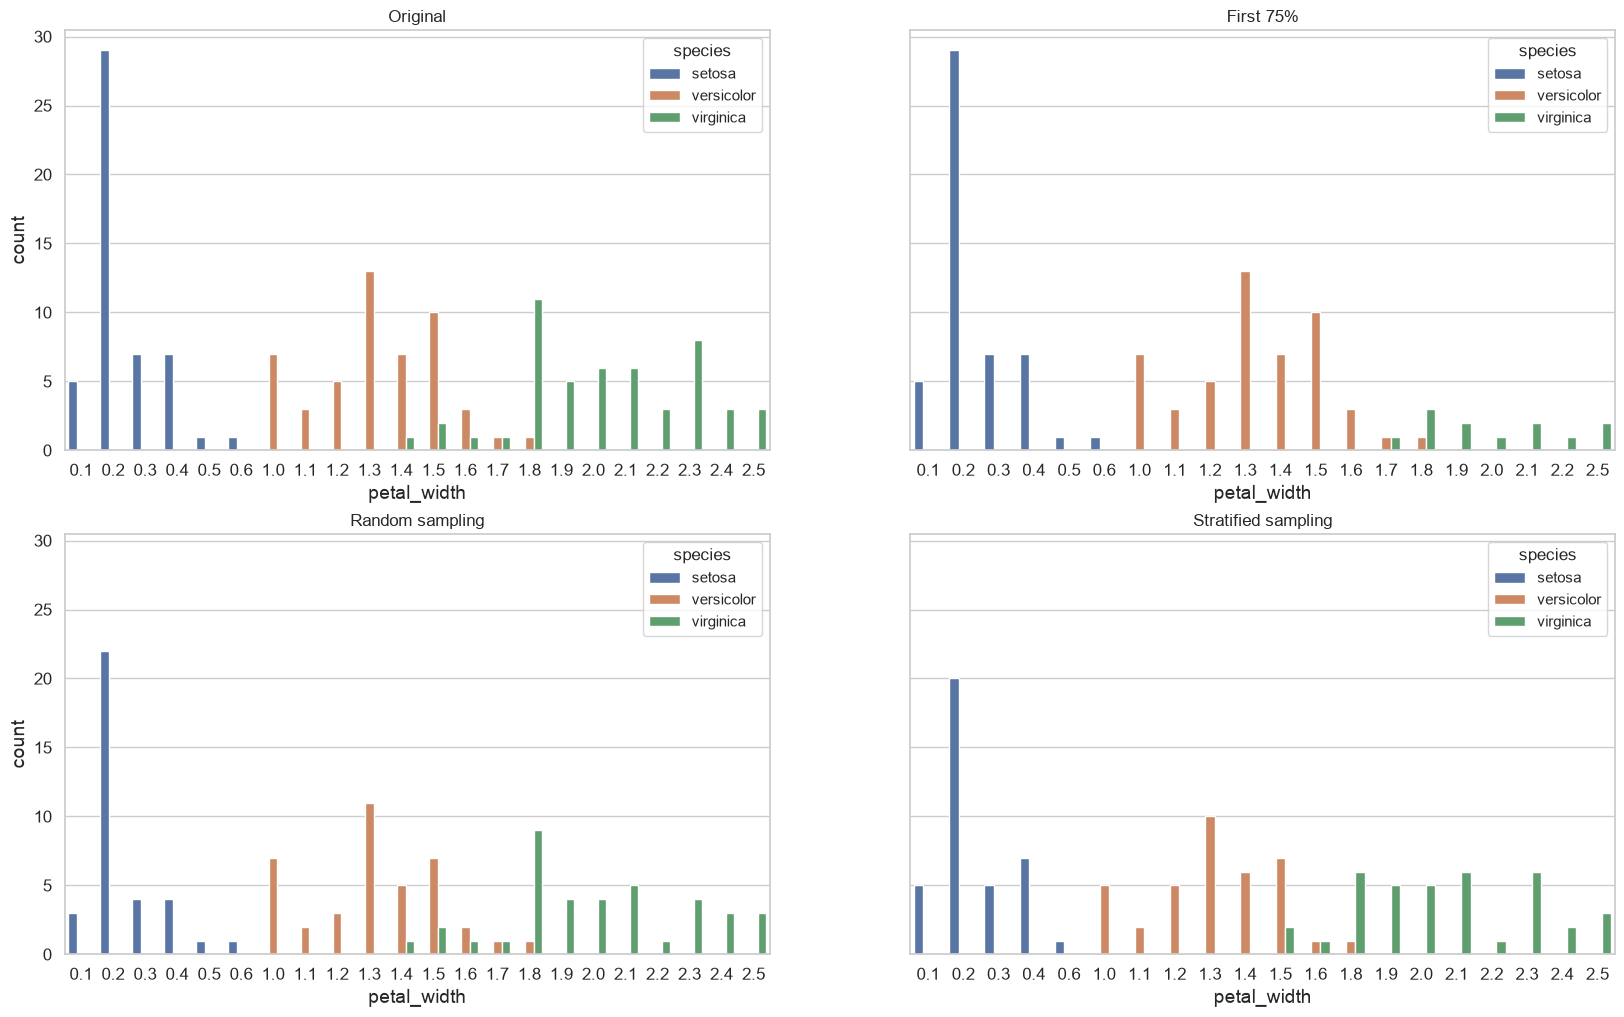

In [9]:
import sklearn.model_selection as sel

# select first 75% of all observations as training set
iris_1 = iris.head(round(len(iris.index)*0.75))
# stratified sampling - same number of observations are selected randomly per class
iris_2 = sel.train_test_split(iris, test_size=0.25, random_state=42, stratify=iris.species)
# random sampling
iris_3 = sel.train_test_split(iris, test_size=0.25, random_state=42)

fig, ax = plt.subplots(2,2, sharey=True, figsize=(20,12))
sns.countplot(x="petal_width", data=iris, hue="species", ax=ax[0,0]).set_title("Original")
sns.countplot(x="petal_width", data=iris_1, hue="species", ax=ax[0,1]).set_title("First 75%")
sns.countplot(x="petal_width", data=iris_2[0].sort_index(), hue="species", ax=ax[1,1]).set_title("Stratified sampling")
sns.countplot(x="petal_width", data=iris_3[0].sort_index(), hue="species", ax=ax[1,0]).set_title("Random sampling")

### Supervised Training & Evaluation in Scikit-Learn

- **Experimental Evaluation**: Find the best neighborhood hyperparameter $k$ using $K$-fold cross-validation with grid search.
- **Experimental Protocol**:
  - Set `random_state` explicitly before experiments to ensure deterministic reproducibility.
  - Use **stratified $K$-fold cross-validation** ($K = 5$) to preserve equal class proportions across all validation splits.
  - *Notation note*: Capital $K$ denotes the number of cross-validation folds ($K = 5$), while lowercase $k$ denotes the neighborhood size ($k$-NN).


In [10]:
def split_data(data, stratify=None, test_size=0.25, random_state=7):
    X = data.drop(columns=['species']).values
    y = data['species'].values
    train_X, test_X, train_y, test_y = sel.train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )
    return train_X, train_y, test_X, test_y


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

def kNN(k=8, test_size=0.25, random_state=7, stratify=0):
    st = None
    if stratify > 0: 
        st = iris['species']

    train_X, train_y, test_X, test_y = split_data(
        iris, stratify=st, test_size=test_size, random_state=random_state
    )

    classifier = KNeighborsClassifier(n_neighbors=k)
    classifier.fit(train_X, train_y)

    # Explicit prediction and performance evaluation
    pred_y = classifier.predict(test_X)
    acc = metrics.accuracy_score(test_y, pred_y)
    print(f"Accuracy: {acc:.4f}")
    print("Correctly classified samples:", np.where(pred_y == test_y)[0])
    print("Samples incorrectly classified:", np.where(pred_y != test_y)[0])

    feature_cols = [c for c in iris.columns if c != 'species']
    hp.plot_knn_results(
        train_X, train_y, test_X, test_y, pred_y,
        target_names=np.unique(iris['species']),
        feature_cols=feature_cols
    )


In [12]:
interact(kNN, k=(2,9,1), test_size=(0.1,0.9,0.15), random_state=(3,11,1), stratify=(0, 1, 1));

interactive(children=(IntSlider(value=8, description='k', max=9, min=2), FloatSlider(value=0.25, description='…

## 6. Hyperparameter Optimization & Cross-Validation

- **Manual Search Limitations**: Evaluating candidates by hand is inefficient and sensitive to split variance:
    - Which neighborhood size $k \in \{1, 3, 5, \dots, k_{\max}\}$ yields the best balance between bias and variance?
    - How can we eliminate reliance on a single arbitrary train-test split?
- **Objective**: Systematically optimize hyperparameters across multiple validation folds.


### Systematic Grid Search & Cross-Validation

- **Grid Search (`GridSearchCV` in `sklearn`)**:
  - **Grid Search**: Exhaustive evaluation over a discrete grid of candidate hyperparameter values (e.g., $k \in \{1, 3, 5, \dots, 21\}$).
  - **$K$-Fold Cross-Validation (CV)**: Splits $\mathcal{D}_{\text{train}}$ into $K$ equal folds; iteratively trains on $K - 1$ folds and evaluates on the remaining validation fold.
  - **Scoring Metric**: Selects the configuration maximizing the mean cross-validation macro $F_1$-score.


In [13]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': range(3, 10)}
knn = KNeighborsClassifier()

# Use 5-fold CV with F1 (macro - average over all classes) to select best k
gscv = GridSearchCV(knn, parameters, scoring='f1_macro', cv=5, verbose=0)
data = iris.iloc[:, range(0, 4)]
target = iris['species']
gscv.fit(data, target)
print(f"Optimal hyperparameter k: {gscv.best_params_['n_neighbors']} (Mean CV F1: {gscv.best_score_:.4f})")


Optimal hyperparameter k: 6 (Mean CV F1: 0.9799)


In [14]:
cvr = pd.DataFrame(gscv.cv_results_)
cvr[['param_n_neighbors','mean_fit_time','mean_test_score',
     'std_test_score','rank_test_score']]

,param_n_neighbors,mean_fit_time,mean_test_score,std_test_score,rank_test_score
0,3,0.001112,0.966482,0.021295,7
1,4,0.001037,0.973266,0.013367,4
2,5,0.001101,0.973165,0.025170,5
3,6,0.000921,0.979950,0.016371,1
4,7,0.000909,0.979950,0.016371,1
5,8,0.000885,0.966650,0.029814,6
6,9,0.000911,0.973300,0.024953,3


## 7. Experiment Tracking with Weights & Biases (W&B)

In [15]:
import os
import wandb
from sklearn.metrics import accuracy_score, f1_score

# Weights & Biases configuration: disable only if no credentials exist
netrc_path = os.path.expanduser("~/.netrc")
has_wandb_creds = bool(
    os.environ.get("WANDB_API_KEY")
    or (os.path.exists(netrc_path) and os.access(netrc_path, os.R_OK))
)
if not has_wandb_creds:
    os.environ["WANDB_MODE"] = "disabled"

def kNN_wandb(k, train_X, train_y, test_X, test_y):
    entity = os.environ.get("WANDB_ENTITY", None)
    with wandb.init(project="ml-knn-project", entity=entity, config={"model": "kNN", "k": k}) as run:
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_X, train_y)
        pred = knn.predict(test_X)
        accuracy = accuracy_score(test_y, pred)
        f1 = f1_score(test_y, pred, average="macro")
        run.log({"accuracy": accuracy, "f1": f1})
        run.summary["accuracy"] = accuracy
        run.summary["f1"] = f1


In [16]:
train_X, train_y, test_X, test_y = split_data(iris, iris.species, test_size=0.25, random_state=57)
kNN_wandb(3, train_X, train_y, test_X, test_y)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.
wandb: Currently logged in as: konstantin-schekotihin (aau-ai-ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


accuracy,▁
f1,▁
accuracy,0.97368
f1,0.97432


In [17]:
sweep_configuration = {
    'method': 'grid',
    'name': 'Grid Search kNN',
    'metric': {
        'goal': 'maximize',
        'name': 'f1',
    },
    'parameters': {
        'n_neighbors': {
            'values': [3, 5, 7, 8, 9]
        },
        'random_state': {
            'values': [3, 5, 7, 9, 11, 42]
        }
    }
}

entity = os.environ.get("WANDB_ENTITY", None)
sweep_id = None
if os.environ.get("WANDB_MODE") not in ["disabled", "offline"]:
    try:
        sweep_id = wandb.sweep(sweep_configuration, project="ml-knn-project", entity=entity)
        print(f"✅ W&B Sweep initialized: {sweep_id}")
    except Exception as e:
        print(f"💡 W&B Cloud Sweep skipped ({e}). Use local GridSearchCV for hyperparameter tuning.")
else:
    print("💡 W&B logging disabled or offline. Provide W&B credentials to initialize cloud sweeps.")


Create sweep with ID: 93mnzsdu
Sweep URL: https://wandb.ai/aau-ai-ml/ml-knn-project/sweeps/93mnzsdu
✅ W&B Sweep initialized: 93mnzsdu


In [ ]:
def sweep_train():
    entity = os.environ.get("WANDB_ENTITY", None)
    with wandb.init(project="ml-knn-project", entity=entity) as run:
        k = wandb.config.n_neighbors
        seed = wandb.config.random_state
        train_X, train_y, test_X, test_y = split_data(iris, iris.species, test_size=0.25, random_state=seed)
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(train_X, train_y)
        pred = knn.predict(test_X)
        accuracy = accuracy_score(test_y, pred)
        f1 = f1_score(test_y, pred, average="macro")
        run.log({"accuracy": accuracy, "f1": f1})
        run.summary["accuracy"] = accuracy
        run.summary["f1"] = f1

# Launch W&B sweep agent to execute hyperparameter trials
if sweep_id and os.environ.get("WANDB_MODE") not in ["disabled", "offline"]:
    print(f"🚀 Launching W&B agent for sweep: {sweep_id}")
    wandb.agent(sweep_id, function=sweep_train, count=30)


🚀 Launching W&B agent for sweep: 93mnzsdu


wandb: Agent Starting Run: oudktwt4 with config:
wandb: 	n_neighbors: 5
wandb: 	random_state: 11
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.


accuracy,▁
f1,▁
accuracy,0.97368
f1,0.97432


wandb: Agent Starting Run: x1l3vfb1 with config:
wandb: 	n_neighbors: 5
wandb: 	random_state: 42
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.


accuracy,▁
f1,▁
accuracy,0.97368
f1,0.97432


...

wandb: Agent Starting Run: dd0kqlq1 with config:
wandb: 	n_neighbors: 9
wandb: 	random_state: 3
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.


accuracy,▁
f1,▁
accuracy,0.94737
f1,0.94589


wandb: Agent Starting Run: g1sfzsp1 with config:
wandb: 	n_neighbors: 9
wandb: 	random_state: 5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.


accuracy,▁
f1,▁
accuracy,0.92105
f1,0.92296


wandb: Agent Starting Run: 5muho5dg with config:
wandb: 	n_neighbors: 9
wandb: 	random_state: 7
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /Users/kostya/.netrc.


## 8. Algorithm Selection Card: $k$-Nearest Neighbors ($k$-NN)

| Dimension | Assessment & Practical Guidance |
| :--- | :--- |
| **Best Suited For** | Multi-class classification with non-linear decision boundaries, low-to-moderate feature dimensionality ($D < 20$), and local clustering patterns. |
| **Key Hyperparameters** | • $k$ (number of neighbors): smaller $k \to$ low bias, high variance (overfitting); larger $k \to$ smoother boundaries, higher bias.<br>• Distance metric ($p=1$ Manhattan, $p=2$ Euclidean, Minkowski).<br>• Weighting scheme (uniform vs. distance-weighted $1/d$). |
| **Interpretability vs. Capacity** | **Moderate / Case-Based**: Highly intuitive to explain to domain stakeholders (*"similar patients had this outcome"*), but lacks an explicit parametric equation or feature weights. |
| **Critical Pitfalls** | • **Feature Scale Sensitivity**: Features with larger numerical ranges dominate distances; **feature standardization (`StandardScaler`) is mandatory**.<br>• **Curse of Dimensionality**: In high dimensions ($D \gg 20$), points become equidistant, degrading neighborhood quality.<br>• **Computational Cost**: Zero training time ($O(1)$ lazy learner), but slow inference time ($O(ND)$ per query). |

> 💡 **Key Takeaway:** For your semester project, $k$-NN serves as an excellent, intuitive **baseline benchmark model**. Always standardize your features and tune $k$ via cross-validation before exploring more complex parametric classifiers.
